# Tennis Doubles Homophily â€” Main Analysis

Data: Grand Slam doubles matches 2018â€“2025 (excl. 2020). N â‰ˆ 1,795 matches after dropping retirements/walkovers.

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions â€” match win / tiebreak win / comeback win

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

Loaded 1,840 matches | years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [2]:
# â”€â”€ Fill missing country from birthplace-country â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Some players (primarily Russian/Belarusian neutrals) have NaN country but a
# populated birthplace-country column. Transfer birthplace-country to country
# before computing homophily variables so those rows are not needlessly dropped.

_prefixes = ['winners_p1', 'winners_p2', 'losers_p1', 'losers_p2']
_filled = {}
for _p in _prefixes:
    _mask = df[f'{_p}_country'].isna() & df[f'{_p}_birthplace-country'].notna()
    _n = _mask.sum()
    if _n:
        df.loc[_mask, f'{_p}_country'] = df.loc[_mask, f'{_p}_birthplace-country']
        _filled[_p] = _n
        print(f'  {_p}: {_n} missing country filled from birthplace-country')

# Recompute same_country for both sides
for _side in ['winners', 'losers']:
    _p1, _p2 = f'{_side}_p1', f'{_side}_p2'
    df[f'same_country_{_side}'] = (
        (df[f'{_p1}_country'] == df[f'{_p2}_country'])
        .where(df[f'{_p1}_country'].notna() & df[f'{_p2}_country'].notna())
        .astype(float)
    )

# For newly resolved same-country pairs: same_language = 1 (same country => same language)
for _side, _p1, _p2 in [('winners','winners_p1','winners_p2'), ('losers','losers_p1','losers_p2')]:
    _newly_same = (df[f'same_country_{_side}'] == 1) & df[f'{_side}_same_language'].isna()
    df.loc[_newly_same, f'{_side}_same_language'] = 1
    df.loc[_newly_same, f'{_side}_linguistic_proximity'] = 1

print(f'same_country_winners NaN: {df["same_country_winners"].isna().sum()} '
      f'(was {57})')
print(f'same_country_losers  NaN: {df["same_country_losers"].isna().sum()} '
      f'(was {93})')

  winners_p1: 4 missing country filled from birthplace-country
  winners_p2: 7 missing country filled from birthplace-country
  losers_p1: 23 missing country filled from birthplace-country
  losers_p2: 21 missing country filled from birthplace-country
same_country_winners NaN: 46 (was 57)
same_country_losers  NaN: 55 (was 93)


In [3]:
# â”€â”€ Fix Olympic player nationality / language data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# ROC (Tokyo 2021) and AIN (Paris 2024) athletes competed as neutral but their
# nationalities are unambiguous. A few 2024 entries also have NaN country.
# Lebanon and Hungary have gaps in the language lookup (same_country=1, same_language=0).

_country_fixes = {
    'karatsev':       'Russia',
    'medvedev':       'Russia',
    'khachanov':      'Russia',
    'rublev':         'Russia',
    'safiullin':      'Russia',
    'gerasimov':      'Belarus',
    'ivashka':        'Belarus',
    'kubot':          'Poland',
    'paul':           'United States',
    'roger-vasselin': 'France',
    'balaji':         'India',
}

olym_idx = df[df['tournament'] == 'Olympics'].index

for prefix in ['winners_p1', 'winners_p2', 'losers_p1', 'losers_p2']:
    surname_col = f'{prefix}_surname'
    country_col = f'{prefix}_country'
    for surname, country in _country_fixes.items():
        fix = (
            df.index.isin(olym_idx) &
            df[surname_col].str.lower().str.strip().eq(surname) &
            df[country_col].isna()
        )
        df.loc[fix, country_col] = country

# Recompute same_country for Olympic rows only
df.loc[olym_idx, 'same_country_winners'] = (
    df.loc[olym_idx, 'winners_p1_country'] == df.loc[olym_idx, 'winners_p2_country']
).astype(float)
df.loc[olym_idx, 'same_country_losers'] = (
    df.loc[olym_idx, 'losers_p1_country'] == df.loc[olym_idx, 'losers_p2_country']
).astype(float)

# Fix same_language / ling_prox for Olympic same-country pairs where lookup was 0
# (covers both newly-fixed pairs and Lebanon/Hungary lookup gaps)
fix_w = df.index.isin(olym_idx) & df['same_country_winners'].eq(1) & df['winners_same_language'].eq(0)
fix_l = df.index.isin(olym_idx) & df['same_country_losers'].eq(1)  & df['losers_same_language'].eq(0)
df.loc[fix_w, ['winners_same_language', 'winners_linguistic_proximity']] = 1
df.loc[fix_l, ['losers_same_language',  'losers_linguistic_proximity']]  = 1

print(f'same_country_winners=0 remaining in Olympics: {(df.loc[olym_idx,"same_country_winners"]==0).sum()}')
print(f'same_country_losers=0  remaining in Olympics: {(df.loc[olym_idx,"same_country_losers"]==0).sum()}')
print(f'winners_same_language=0 remaining in Olympics: {(df.loc[olym_idx,"winners_same_language"]==0).sum()}')
print(f'losers_same_language=0  remaining in Olympics: {(df.loc[olym_idx,"losers_same_language"]==0).sum()}')

same_country_winners=0 remaining in Olympics: 0
same_country_losers=0  remaining in Olympics: 0
winners_same_language=0 remaining in Olympics: 0
losers_same_language=0  remaining in Olympics: 0


## 1. Variable Construction

In [4]:
# â”€â”€ Tiebreak flags â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Drop likely retirements/walkovers that are not explicitly flagged in the data.
# A valid completed set is 6-0 through 6-4, 7-5, 7-6, or an extended final set
# score with a two-game margin (e.g. 8-6, 9-7). If the first two sets are split,
# the third set must also be complete, either as a regular set or as a match tiebreak.
def regular_set_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (
        ((hi == 6) & (lo <= 4)) |
        ((hi == 7) & lo.isin([5, 6])) |
        ((hi >= 8) & ((hi - lo) == 2))
    )

def match_tiebreak_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 10) & ((hi - lo) >= 2)

s1_complete = regular_set_complete(df['winners_set1'], df['losers_set1'])
s2_complete = regular_set_complete(df['winners_set2'], df['losers_set2'])
split_sets = (
    ((df['winners_set1'] > df['losers_set1']) & (df['winners_set2'] < df['losers_set2'])) |
    ((df['winners_set1'] < df['losers_set1']) & (df['winners_set2'] > df['losers_set2']))
)
s3_complete = (
    regular_set_complete(df['winners_set3'], df['losers_set3']) |
    match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
)
retired_or_incomplete = ~s1_complete | ~s2_complete | (split_sets & ~s3_complete)
print(f'Dropping likely retirements/walkovers: {retired_or_incomplete.sum():,} matches')
df = df.loc[~retired_or_incomplete].copy()

# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point, set3 â‰¥ 10): Olympics and Wimbledon post-2018
df['match_tb'] = match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
df['any_tb']   = df['regular_tb'] | df['match_tb'] | df['tb_s3_regular']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)

# â”€â”€ Match structure â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']   # winner came back from 0-1 down

# â”€â”€ Olympic period flags â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def get_period(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    elif y == 2020:
        if t != 'Wimbledon':  # Exclude Wimbledon 2020
            return 'Tokyo Prep'
        else:
            return None  # Exclude Wimbledon 2020
    elif y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        elif t == 'US Open':
            return 'Post-Tokyo'
    elif y == 2022:
        return 'Pre-Paris'
    elif y == 2023:
        return 'Paris Prep'
    elif y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        elif t == 'US Open':
            return 'Post-Paris'
    elif y == 2025:
        return 'Post-Paris'
    return None

df['cycle'] = df.apply(get_period, axis=1)
df['pre_olympic']   = df['cycle'].isin(['Pre-Paris', 'Paris Prep']).astype(int)   # Pre-Paris and Paris Prep
df['olympic_period']= df['cycle'].isin(['Pre-Paris', 'Paris Prep', 'Post-Paris']).astype(int)
df['olympics_tourn']= (df['tournament'] == 'Olympics').astype(int)

# â”€â”€ Match-level homophily differences (winner âˆ’ loser) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
df['ling_prox_diff']     = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

# Match-level averages (across both teams)

df['same_country_avg']   = (df['same_country_winners'] + df['same_country_losers']) / 2 
df['same_language_avg']  = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']      = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2
print('Variable construction complete.')

Dropping likely retirements/walkovers: 47 matches


Variable construction complete.


In [5]:
# â”€â”€ Verify dropped matches â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Each dropped match is classified as:
#   WALKOVER       : all set scores NaN (match never played)
#   RETIREMENT-S1  : set-2 score missing (retired during/after set 1)
#   RETIREMENT-S2+ : sets 1+2 complete but set-3 score missing (retired in set 3)
#   ABBREVIATED    : valid retirement/walkover where the player name uses only an
#                    initial (e.g. "A" from "A Ramos-ViÃ±olas") â€” caught correctly
#                    by the score-completeness filter

def _classify_dropped(row):
    w1 = row.get("winners_set1")
    l1 = row.get("losers_set1")
    w2 = row.get("winners_set2")
    l2 = row.get("losers_set2")
    if pd.isna(w1) and pd.isna(l1):
        return "WALKOVER"
    if pd.notna(w1) and pd.notna(l1) and pd.notna(w2) and pd.notna(l2):
        return "RETIREMENT-S2+"
    return "RETIREMENT-S1"

df_full = pd.read_excel(
    f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx",
    sheet_name="players_list"
)

def _s1c(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (((hi==6)&(lo<=4))|((hi==7)&lo.isin([5,6]))|((hi>=8)&((hi-lo)==2)))

def _tb3(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 10) & ((hi - lo) >= 2)

_s1f = _s1c(df_full["winners_set1"], df_full["losers_set1"])
_s2f = _s1c(df_full["winners_set2"], df_full["losers_set2"])
_spf = (
    ((df_full["winners_set1"]>df_full["losers_set1"])&(df_full["winners_set2"]<df_full["losers_set2"])) |
    ((df_full["winners_set1"]<df_full["losers_set1"])&(df_full["winners_set2"]>df_full["losers_set2"]))
)
_s3f = _s1c(df_full["winners_set3"],df_full["losers_set3"]) | _tb3(df_full["winners_set3"],df_full["losers_set3"])
_ret_mask = ~_s1f | ~_s2f | (_spf & ~_s3f)

dropped_full = df_full[_ret_mask].copy()
dropped_full["drop_reason"] = dropped_full.apply(_classify_dropped, axis=1)

print(f"Total dropped: {len(dropped_full)}")
print(f"Full dataset rows: {len(df_full)}")
print()
print("=== Drop reasons ===")
print(dropped_full["drop_reason"].value_counts().to_string())
print()
print("=== WALKOVER ===")
wo = dropped_full[dropped_full["drop_reason"]=="WALKOVER"]
print(wo[["year","tournament","stage","winners_p1_name","winners_p2_name","losers_p1_name","losers_p2_name"]].to_string(index=False))
print()
print("=== Genuine retirements ===")
ret = dropped_full[dropped_full["drop_reason"].str.startswith("RETIREMENT")]
print(ret[["year","tournament","stage","drop_reason",
           "winners_p1_name","losers_p1_name",
           "winners_set1","losers_set1","winners_set2","losers_set2",
           "winners_set3","losers_set3"]].to_string(index=False))

Total dropped: 47
Full dataset rows: 1840

=== Drop reasons ===
drop_reason
WALKOVER          20
RETIREMENT-S2+    18
RETIREMENT-S1      9

=== WALKOVER ===
 year      tournament       stage winners_p1_name winners_p2_name losers_p1_name losers_p2_name
 2018 Australian Open Round of 32               j               f              n              m
 2018 Australian Open Round of 16               m           a-u-h              r              h
 2019         US Open Round of 32               r               d              m              a
 2019         US Open Round of 32               o               j              m              n
 2021        Olympics Round of 16          marcus         michael         wesley    jean-julien
 2021   Roland Garros Round of 16               r               f              m              m
 2021         US Open Round of 32               d               e              n              j
 2021       Wimbledon Round of 16               Å‚               m         

## 2. Pressure Outcomes â€” Counts and Inspection

In [6]:
print(f'=== Table 1. Pressure Outcome Counts (all matches, N={len(df):,}) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                          df['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',                  df['tb_s3_regular']),
    ('Match tiebreak / super-tb (10-pt, set3 â‰¥ 8)',   df['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',             df['regular_tb']),
    ('Any tiebreak (all types)',                       df['any_tb']),
    ('Match went to 3 sets',                           df['three_sets']),
    ('Comeback wins (winner lost set 1)',               df['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('Regular tiebreaks by tournament:')
print(df.groupby('tournament')['regular_tb'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

print()
print('Match tiebreaks (super-tb) by tournament/year:')
print(df[df['match_tb']].groupby(['tournament','year']).size().to_frame('N').to_string())

print()
print('Comeback wins by tournament:')
print(df.groupby('tournament')['comeback'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

=== Table 1. Pressure Outcome Counts (all matches, N=1,793) ===
  Set-1 tiebreak (7-pt)                               N= 445  (24.8%)
  Set-2 tiebreak (7-pt)                               N= 470  (26.2%)
  Set-3 regular tiebreak (7-pt)                       N= 195  (10.9%)
  Match tiebreak / super-tb (10-pt, set3 â‰¥ 8)         N=  24  (1.3%)
  Any regular tiebreak (sets 1 or 2)                  N= 804  (44.8%)
  Any tiebreak (all types)                            N= 896  (50.0%)
  Match went to 3 sets                                N= 787  (43.9%)
  Comeback wins (winner lost set 1)                   N= 351  (19.6%)

Regular tiebreaks by tournament:
                   N   Rate
tournament                 
Australian Open  197 0.4590
Olympics          28 0.4440
Roland Garros    148 0.3440
US Open          206 0.4760
Wimbledon        225 0.5140

Match tiebreaks (super-tb) by tournament/year:
                  N
tournament year    
Olympics   2021   9
           2024  11
Wimbledon  2018  

### 2.1 Tiebreak types treated together vs separately

Regular tiebreaks (7-point, in sets 1-2) and match tiebreaks (10-point super-tiebreak, set 3) measure the same underlying construct â€” pressure in a closely contested set â€” but with different point thresholds. For regression purposes we treat them together as `any_tb`. Match tiebreaks are few (N=30) and concentrated in the Olympics and Wimbledon.

## 3. Olympic Cycle Descriptive Evidence


In [7]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']

def assign_tokyo_cycle(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    if y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    if y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        if t == 'US Open':
            return 'Post-Tokyo'
    if y == 2022:
        return 'Post-Tokyo'
    return None


def assign_paris_cycle(row):
    y = row['year']
    t = row['tournament']

    if y == 2022:
        return 'Pre-Paris'

    if y == 2023:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']:
            return 'Paris Prep'

    if y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        if t == 'US Open':
            return 'Post-Paris'

    if y == 2025:
        return 'Post-Paris'

    return None

gs['cycle_tokyo'] = gs.apply(assign_tokyo_cycle, axis=1)
gs['cycle_paris'] = gs.apply(assign_paris_cycle, axis=1)

cycle_order_tokyo = ['Pre-Tokyo', 'Tokyo Prep', 'Post-Tokyo']
cycle_order_paris = ['Pre-Paris', 'Paris Prep', 'Post-Paris']

panel_tokyo = pd.DataFrame({
    'Period': cycle_order_tokyo,
    'Calendar window': ['Jan 2018 â€“ Dec 2019', 'Jan 2020 â€“ Jul 2021', 'Aug 2021 â€“ Dec 2022'],
    'GS included': ['AO18â€“USO19', 'AO20â€“Wim21 (ex Wim20)', 'USO21â€“USO22'],
}).set_index('Period')

panel_paris = pd.DataFrame({
    'Period': cycle_order_paris,
    'Calendar window': ['Jan 2022 â€“ Dec 2022', 'Jan 2023 â€“ Jul 2024', 'Aug 2024 â€“ Dec 2025'],
    'GS included': ['AO22â€“USO22', 'AO23â€“Wim24', 'USO24â€“USO25'],
}).set_index('Period')

by_tokyo = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo')[hcols].mean().reindex(cycle_order_tokyo) * 100
by_tokyo.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_tokyo['N teams'] = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo').size().reindex(cycle_order_tokyo) * 2

by_paris = gs[gs['cycle_paris'].notna()].groupby('cycle_paris')[hcols].mean().reindex(cycle_order_paris) * 100
by_paris.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_paris['N teams'] = gs[gs['cycle_paris'].notna()].groupby('cycle_paris').size().reindex(cycle_order_paris) * 2

panel_tokyo = panel_tokyo.join(by_tokyo)
panel_paris = panel_paris.join(by_paris)

print('=== Table 2A. Tokyo 2021 cycle â€” Same nat/lang/langprox by period ===')
print(panel_tokyo.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('=== Table 2B. Paris 2024 cycle â€” Same nat/lang/langprox by period ===')
print(panel_paris.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('Overall same vs. diff homophily rates (Grand Slams, all teams):')
for avg_col, lbl in [
    ('same_country_avg',  'Same nationality'),
    ('same_language_avg', 'Same language'),
    ('ling_prox_avg',     'Ling. proximity'),
]:
    same_pct = 100 * gs[avg_col].mean()
    print(f'  {lbl:<25s}  Same={same_pct:.1f}%  Diff={(100-same_pct):.1f}%')

=== Table 2A. Tokyo 2021 cycle â€” Same nat/lang/langprox by period ===
                Calendar window            GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                           
Pre-Tokyo   Jan 2018 â€“ Dec 2019             AO18â€“USO19           40.1000        55.1000          55.9000     1006
Tokyo Prep  Jan 2020 â€“ Jul 2021  AO20â€“Wim21 (ex Wim20)           42.0000        56.1000          56.1000      364
Post-Tokyo  Aug 2021 â€“ Dec 2022            USO21â€“USO22           39.2000        54.8000          55.5000      604

=== Table 2B. Paris 2024 cycle â€” Same nat/lang/langprox by period ===
                Calendar window  GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                 
Pre-Paris   Jan 2022 â€“ Dec 2022   AO22â€“USO22           39.300

In [8]:
# Same vs. diff homophily by year and tournament
avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
by_year_tourn = gs.groupby(['year', 'tournament'])[avg_cols].mean() * 100
by_year_tourn.columns = ['Same Nationality (%)', 'Same Language (%)', 'Ling. Proximity (%)']
by_year_tourn['Diff Nationality (%)'] = 100 - by_year_tourn['Same Nationality (%)']
by_year_tourn['Diff Language (%)'] = 100 - by_year_tourn['Same Language (%)']
by_year_tourn['Diff Ling. Proximity (%)'] = 100 - by_year_tourn['Ling. Proximity (%)']
by_year_tourn = by_year_tourn[['Same Nationality (%)', 'Diff Nationality (%)',
                                'Same Language (%)', 'Diff Language (%)',
                                'Ling. Proximity (%)', 'Diff Ling. Proximity (%)']]
print('=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===')
print(by_year_tourn.round(1).to_string())

=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===
                      Same Nationality (%)  Diff Nationality (%)  Same Language (%)  Diff Language (%)  Ling. Proximity (%)  Diff Ling. Proximity (%)
year tournament                                                                                                                                      
2018 Australian Open               38.9000               61.1000            54.1000            45.9000              55.1000                   44.9000
     Roland Garros                 40.5000               59.5000            56.0000            44.0000              59.5000                   40.5000
     US Open                       37.1000               62.9000            51.6000            48.4000              51.6000                   48.4000
     Wimbledon                     29.0000               71.0000            51.5000            48.5000              51.5000                   48.5000
2019 Australian 

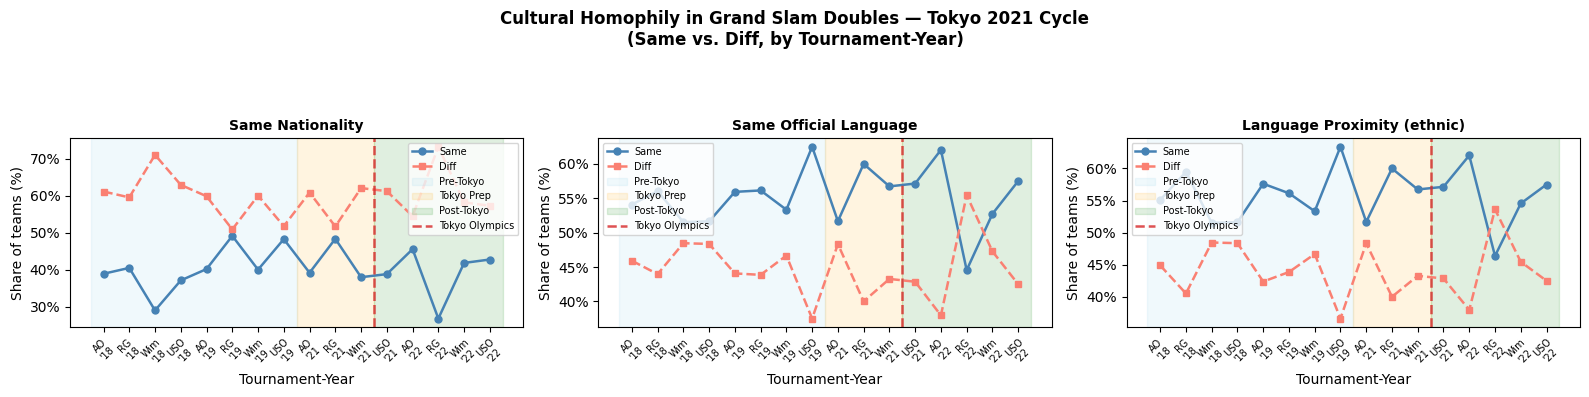

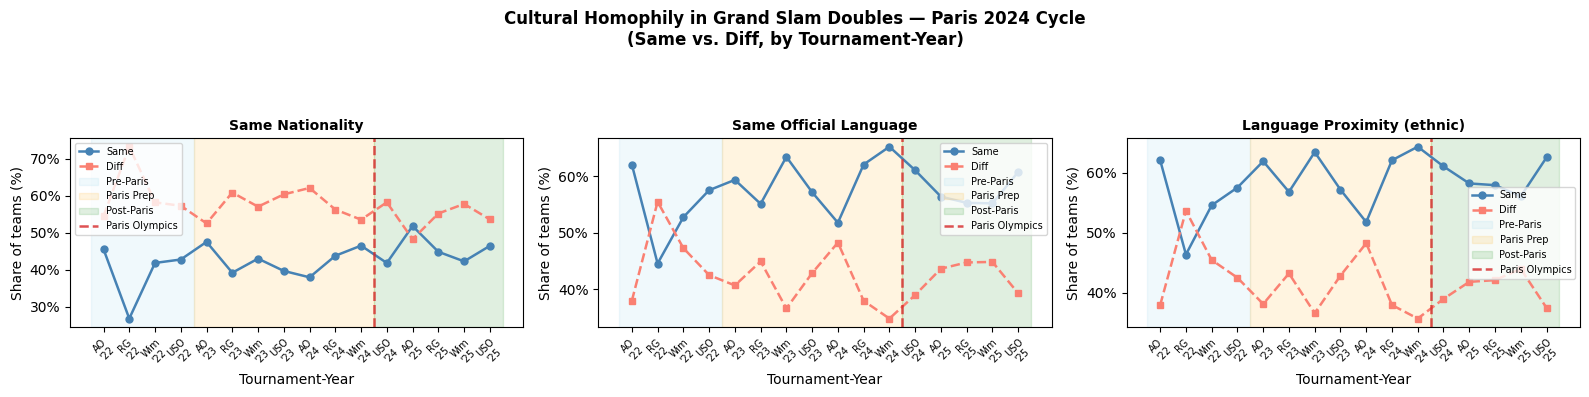

In [9]:
TOURN_ORDER = {'Australian Open': 0, 'Roland Garros': 1, 'Wimbledon': 2, 'US Open': 3}
TOURN_ABBR  = {'Australian Open': 'AO', 'Roland Garros': 'RG', 'Wimbledon': 'Wim', 'US Open': 'USO'}

avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
titles   = ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']

# Chronologically-ordered tournament-year means
ty = gs.groupby(['year', 'tournament'])[avg_cols].mean().mul(100).reset_index()
ty['t_order'] = ty['tournament'].map(TOURN_ORDER)
ty = ty.sort_values(['year', 't_order']).reset_index(drop=True)
ty['label'] = ty.apply(lambda r: f"{TOURN_ABBR[r['tournament']]}\n'{str(r['year'])[2:]}", axis=1)

# â”€â”€ Tokyo cycle â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ty_t = ty[ty['year'].isin([2018, 2019, 2021, 2022])].reset_index(drop=True)
ty_t['x'] = ty_t.index

pre_t  = ty_t['year'].isin([2018, 2019])
prep_t = (ty_t['year'] == 2021) & ty_t['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
post_t = ((ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open')) | (ty_t['year'] == 2022)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_t['x'], ty_t[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_t['x'], 100-ty_t[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_t, 'skyblue', 'Pre-Tokyo'), (prep_t, 'orange', 'Tokyo Prep'), (post_t, 'green', 'Post-Tokyo')]:
        xs = ty_t.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Tokyo Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_t['x']); ax.set_xticklabels(ty_t['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles â€” Tokyo 2021 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_tokyo_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# â”€â”€ Paris cycle â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ty_p = ty[ty['year'].isin([2022, 2023, 2024, 2025])].reset_index(drop=True)
ty_p['x'] = ty_p.index

pre_p  = ty_p['year'] == 2022
prep_p = (ty_p['year'] == 2023) | ((ty_p['year'] == 2024) & ty_p['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
post_p = ((ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open')) | (ty_p['year'] == 2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_p['x'], ty_p[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_p['x'], 100-ty_p[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_p, 'skyblue', 'Pre-Paris'), (prep_p, 'orange', 'Paris Prep'), (post_p, 'green', 'Post-Paris')]:
        xs = ty_p.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Paris Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_p['x']); ax.set_xticklabels(ty_p['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles â€” Paris 2024 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_paris_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

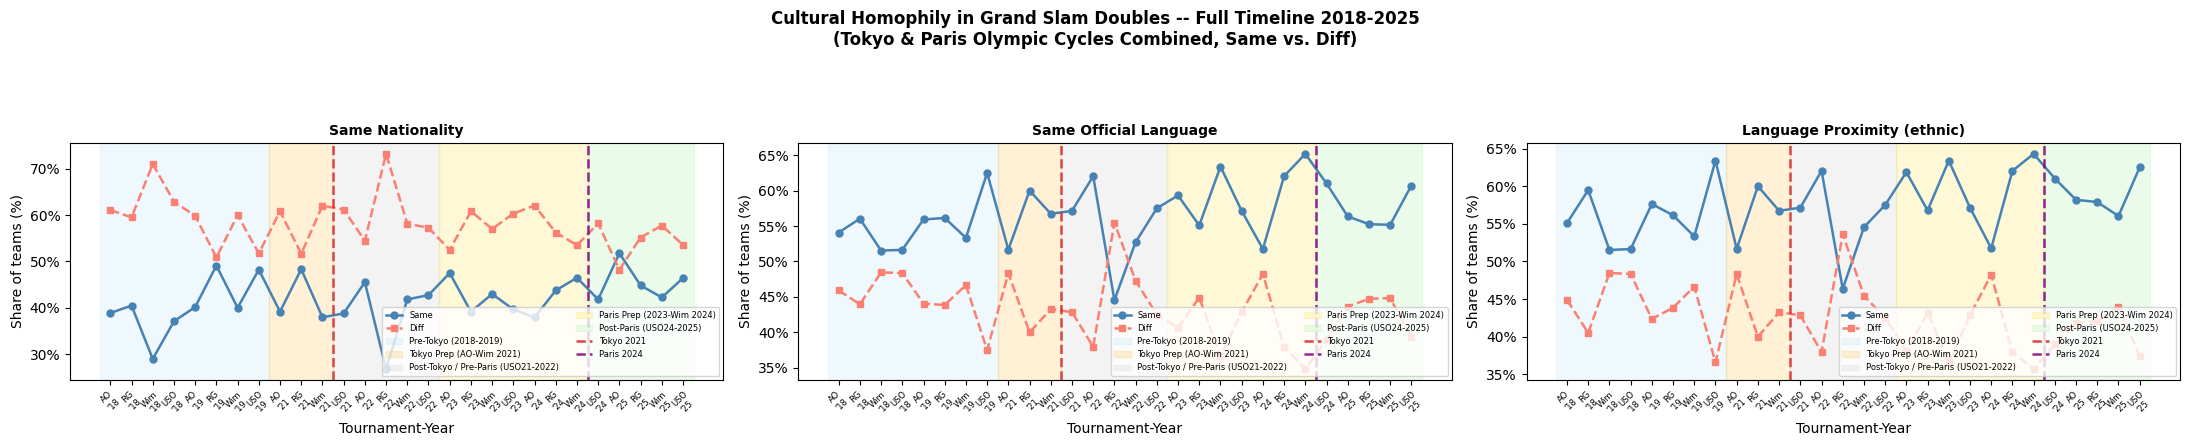

In [10]:
# Combined Tokyo + Paris cycle graph (full timeline 2018-2025)
# Single figure spanning all Grand Slams in the dataset (Olympics excluded).
# Two vertical lines mark the Olympic tournaments; shaded bands show each period.

ty_full = ty.copy()
ty_full['x'] = ty_full.index   # ty already sorted chronologically

mask_pre_tokyo  = ty_full['year'].isin([2018, 2019])
mask_tokyo_prep = (ty_full['year'] == 2021) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
mask_interlude  = ((ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2022)
mask_paris_prep = (ty_full['year'] == 2023) | ((ty_full['year'] == 2024) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
mask_post_paris = ((ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2025)

x_wim21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open'),   'x'].values
x_wim24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open'),   'x'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 4.5), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_full['x'], ty_full[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_full['x'], 100 - ty_full[ac], marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')

    shades = [
        (mask_pre_tokyo,  'skyblue',    0.13, 'Pre-Tokyo (2018-2019)'),
        (mask_tokyo_prep, 'orange',     0.16, 'Tokyo Prep (AO-Wim 2021)'),
        (mask_interlude,  'lightgray',  0.25, 'Post-Tokyo / Pre-Paris (USO21-2022)'),
        (mask_paris_prep, 'gold',       0.16, 'Paris Prep (2023-Wim 2024)'),
        (mask_post_paris, 'lightgreen', 0.18, 'Post-Paris (USO24-2025)'),
    ]
    for mask, color, alpha, lbl in shades:
        xs = ty_full.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=alpha, color=color, label=lbl)

    if len(x_wim21) and len(x_uso21):
        ax.axvline((x_wim21[0] + x_uso21[0]) / 2, color='#d62728', ls='--', lw=1.8, alpha=0.85, label='Tokyo 2021')
    if len(x_wim24) and len(x_uso24):
        ax.axvline((x_wim24[0] + x_uso24[0]) / 2, color='purple',  ls='--', lw=1.8, alpha=0.85, label='Paris 2024')

    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year')
    ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_full['x'])
    ax.set_xticklabels(ty_full['label'], fontsize=6)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=6, ncol=2, loc='lower right')

fig.suptitle('Cultural Homophily in Grand Slam Doubles -- Full Timeline 2018-2025\n'
             '(Tokyo & Paris Olympic Cycles Combined, Same vs. Diff)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_combined_cycles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Team Panel Construction

Convert match-level data to team-level panel: each match creates 2 observations (winners=1, losers=0).


In [11]:
# Build team panel (match-level to team-level: winners row + losers row)
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','regular_tb','match_tb','tb_s3_regular',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

# Winners row
w_row = df[match_vars].copy()
for col, src in [('same_country','same_country_winners'),('same_language','winners_same_language'),
                 ('ling_prox','winners_linguistic_proximity'),('rank_mean','rank_mean_winners'),
                 ('wl_career_diff','wl_career_diff_winners'),('rank_gap','rank_diff_winners')]:
    w_row[col] = df[src].values
w_row['single_top100'] = ((df['winners_p1_top100_within_1y']==1) | (df['winners_p2_top100_within_1y']==1)).astype(int)
w_row['win'] = 1
w_row['won_tb_s1'] = df['w_won_tb_s1'].values
w_row['won_tb_s2'] = df['w_won_tb_s2'].values

# Losers row
l_row = df[match_vars].copy()
for col, src in [('same_country','same_country_losers'),('same_language','losers_same_language'),
                 ('ling_prox','losers_linguistic_proximity'),('rank_mean','rank_mean_losers'),
                 ('wl_career_diff','wl_career_diff_losers'),('rank_gap','rank_diff_losers')]:
    l_row[col] = df[src].values
l_row['single_top100'] = ((df['losers_p1_top100_within_1y']==1) | (df['losers_p2_top100_within_1y']==1)).astype(int)
l_row['win'] = 0
l_row['won_tb_s1'] = (df['tb_s1'] & (df['winners_set1']==6)).values
l_row['won_tb_s2'] = (df['tb_s2'] & (df['winners_set2']==6)).values

# Team-level experience: avg GS doubles appearances across both players (values <=0 treated as NaN)
for _row, _p1c, _p2c in [
    (w_row, 'winners_p1_experience_double', 'winners_p2_experience_double'),
    (l_row, 'losers_p1_experience_double',  'losers_p2_experience_double'),
]:
    _e1 = df[_p1c].where(df[_p1c] > 0).values.astype(float)
    _e2 = df[_p2c].where(df[_p2c] > 0).values.astype(float)
    with np.errstate(all='ignore'):
        _exp = np.nanmean(np.column_stack([_e1, _e2]), axis=1)
    _exp[np.isnan(_e1) & np.isnan(_e2)] = np.nan
    _row['exp_mean'] = _exp

# Concatenate and compute derived variables
team_df = pd.concat([w_row, l_row], ignore_index=True)
team_df['opp_rank_mean'] = team_df.groupby('match_id')['rank_mean'].transform('sum') - team_df['rank_mean']
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)
team_df['lost_set1'] = np.where(team_df['win']==1, team_df['winner_lost_s1'], ~team_df['winner_lost_s1'])
team_df['comeback'] = (team_df['win'] & team_df['lost_set1']).astype(int)

# Convert booleans to int
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool','boolean','Int64','Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

# Drop entire matches with incomplete ranking or nationality data
bad_rank = set(team_df.loc[team_df['rank_mean'].isna(), 'match_id'])
bad_nat  = set(
    team_df.loc[team_df[['same_country','same_language','ling_prox']].isna().any(axis=1), 'match_id']
)
bad_matches = bad_rank | bad_nat
n_rank = len(bad_rank)
n_nat  = len(bad_nat - bad_rank)

team_df = team_df[~team_df['match_id'].isin(bad_matches)].reset_index(drop=True)

print(f'Team panel constructed: {len(team_df):,} obs | {team_df["match_id"].nunique():,} matches')
print(f'  Dropped {n_rank} matches: ranking incomplete (both players on one team unranked)')
print(f'  Dropped {n_nat} matches: nationality/language data missing for at least one player')
print(f'  Total matches dropped: {len(bad_matches)}')
print(f'  exp_mean coverage: {team_df["exp_mean"].notna().sum():,} / {len(team_df):,} obs ({100*team_df["exp_mean"].notna().mean():.1f}%)')


Team panel constructed: 3,310 obs | 1,655 matches
  Dropped 14 matches: ranking incomplete (both players on one team unranked)
  Dropped 124 matches: nationality/language data missing for at least one player
  Total matches dropped: 138
  exp_mean coverage: 3,112 / 3,310 obs (94.0%)


## 4. Baseline Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Each culture measure (`same_country`, `same_language`, `ling_prox`) is entered one at a time.  
Controls: team average doubles ranking, opponent ranking, teammate rank gap, top-100 singles indicator.  
Fixed effects: tournament-by-year interaction, round (stage_code).  
Standard errors clustered by match.

In [12]:
# Grand Slams panel (Olympics excluded)
# Cell 14 already dropped incomplete-ranking and incomplete-nationality matches from team_df
team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['rank_mean', 'rank_gap']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)
team_gs['won_any_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1) |
                         (team_gs['match_tb'] == 1) | (team_gs['tb_s3_regular'] == 1)).astype(int)

gs_matches = team_gs['match_id'].nunique()
mc = team_gs.groupby('match_id').size()
print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {gs_matches:,} unique matches')
print(f'  Complete pairs (2 obs): {(mc==2).sum():,}  |  Singleton obs (rank or nat/lang incomplete): {(mc==1).sum():,}')

# Panel including Olympics
team_all = team_df.dropna(subset=['rank_mean', 'rank_gap']).copy()
team_all['won_regular_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1)).astype(int)
team_all['won_any_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1) |
                          (team_all['match_tb'] == 1) | (team_all['tb_s3_regular'] == 1)).astype(int)
print(f'Team panel (incl. Olympics):   {len(team_all):,} obs | {team_all["match_id"].nunique():,} unique matches')

Team panel (Grand Slams only): 3,198 obs | 1,599 unique matches
  Complete pairs (2 obs): 1,599  |  Singleton obs (rank or nat/lang incomplete): 0
Team panel (incl. Olympics):   3,310 obs | 1,655 unique matches


In [13]:
output_gs  = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv'
output_all = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv'
team_gs.to_csv(output_gs,  index=False)
team_all.to_csv(output_all, index=False)
print(f'Grand Slams panel saved to {output_gs}')
print(f'Full panel (incl. Olympics) saved to {output_all}')

Grand Slams panel saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv
Full panel (incl. Olympics) saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv


In [14]:
FE = '+ C(tournament):C(year) + C(stage_code)'

CULTURE_VARS = [
    ('same_country',  'Same nationality'),
    ('same_language', 'Same official language'),
    ('ling_prox',     'Language proximity (ethnic)'),
]

CONTROLS = 'rank_mean + opp_rank_mean + rank_gap + single_top100'

ctrl_vars = [
    ('rank_mean',      'Team avg doubles ranking'),
    ('opp_rank_mean',  'Opponent avg doubles ranking'),
    ('rank_gap',       'Teammate rank gap'),
    ('single_top100',  'Top-100 singles player'),
]

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params:
            continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {prefix}{lbl:<42s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')

In [15]:
print('=== Table 3. Match Win -- Logit ===')
print('FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only')
print('\nSample means \u2014 rank_mean | opp_rank_mean | rank_gap:')
for _lbl, _sub in [('  Winners (win=1)', team_gs[team_gs['win']==1]),
                   ('  Losers  (win=0)', team_gs[team_gs['win']==0]),
                   ('  Combined        ', team_gs)]:
    print(f'{_lbl}: {_sub["rank_mean"].mean():.1f} | {_sub["opp_rank_mean"].mean():.1f} | {_sub["rank_gap"].mean():.1f}')

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)


In [ ]:
print('=== Table 3b. Match Win + Experience Controls -- Logit ===')
print('Full GS sample. Adds team avg GS doubles appearances (exp_mean) and its square.')
print('Obs missing experience for both players are dropped from this spec only.')

CONTROLS_EXP = 'rank_mean + opp_rank_mean + rank_gap + single_top100 + exp_mean + exp_mean_sq'
exp_ctrl_vars = [
    ('exp_mean',    'Team avg GS appearances'),
    ('exp_mean_sq', 'GS experience squared'),
]

gs_exp = team_gs.dropna(subset=['exp_mean']).copy()
gs_exp['exp_mean_sq'] = gs_exp['exp_mean'] ** 2
print()
print(f'N={len(gs_exp):,} obs | {gs_exp["match_id"].nunique():,} matches (main table: {len(team_gs):,})')
print(f'  exp_mean: min={gs_exp["exp_mean"].min():.1f}  mean={gs_exp["exp_mean"].mean():.1f}  max={gs_exp["exp_mean"].max():.1f}')

for cvar, clbl in CULTURE_VARS:
    try:
        res = smf.logit(f'win ~ {cvar} + {CONTROLS_EXP} {FE}', data=gs_exp).fit(
            cov_type='cluster', cov_kwds={'groups': gs_exp['match_id']}, disp=False)
        print()
        print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
        show_vars(res, [(cvar, clbl)] + ctrl_vars + exp_ctrl_vars)
    except Exception as e:
        print(f'  [{clbl}] failed: {e}')


In [16]:
print('=== Table 4. Match Win in Tiebreak Matches -- Logit ===')
print('Sample: GS matches with any tiebreak (7-pt set 1/2 or 10-pt match-TB)')
print('Outcome: match win (win=1 winner team, win=0 loser team)')
print('FE: tournament x year + round | SE clustered by match')

tb_any = team_gs[team_gs['any_tb'] == 1].copy()
tb_any_matches = tb_any['match_id'].nunique()
print(f'\nN={len(tb_any):,} team-obs | {tb_any_matches:,} matches')
print('  Sample means \u2014 rank_mean | opp_rank_mean | rank_gap:')
for _lbl, _sub in [('    Match winners (win=1)', tb_any[tb_any['win']==1]),
                   ('    Match losers  (win=0)', tb_any[tb_any['win']==0]),
                   ('    Combined              ', tb_any)]:
    print(f'{_lbl}: {_sub["rank_mean"].mean():.1f} | {_sub["opp_rank_mean"].mean():.1f} | {_sub["rank_gap"].mean():.1f}')

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=tb_any).fit(
        cov_type='cluster', cov_kwds={'groups': tb_any['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)


In [17]:
print('=== Table 4b. Match Win in Tiebreak Matches + Experience Controls -- Logit ===')
print('Sample: GS matches with any tiebreak (7-pt or 10-pt). Outcome: match win.')
print('Adds team avg GS doubles appearances (exp_mean) and its square.')
print('Obs with missing experience for both players are dropped from this spec only.')

CONTROLS_EXP = 'rank_mean + opp_rank_mean + rank_gap + single_top100 + exp_mean + exp_mean_sq'
exp_ctrl_vars = [
    ('exp_mean',    'Team avg GS appearances'),
    ('exp_mean_sq', 'GS experience squared'),
]

tb_any_exp = tb_any.dropna(subset=['exp_mean']).copy()
tb_any_exp['exp_mean_sq'] = tb_any_exp['exp_mean'] ** 2
print(f'\nN={len(tb_any_exp):,} obs | {tb_any_exp["match_id"].nunique():,} matches (main table: {len(tb_any):,})')
print(f'  exp_mean: min={tb_any_exp["exp_mean"].min():.1f}  mean={tb_any_exp["exp_mean"].mean():.1f}  max={tb_any_exp["exp_mean"].max():.1f}')

for cvar, clbl in CULTURE_VARS:
    try:
        res = smf.logit(f'win ~ {cvar} + {CONTROLS_EXP} {FE}', data=tb_any_exp).fit(
            cov_type='cluster', cov_kwds={'groups': tb_any_exp['match_id']}, disp=False)
        print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
        show_vars(res, [(cvar, clbl)] + ctrl_vars + exp_ctrl_vars)
    except Exception as e:
        print(f'  [{clbl}] failed: {e}')


In [ ]:
print('=== Table 4c. Match Win, Last-Set Tiebreak Only -- Logit ===')
print('Sample: GS matches decided by a last-set tiebreak (set-3 regular 7-pt or 10-pt match TB).')
print('Outcome: match win. FE: tournament x year + round | SE clustered by match')

tb_last = team_gs[(team_gs['tb_s3_regular']==1) | (team_gs['match_tb']==1)].copy()
tb_last_matches = tb_last['match_id'].nunique()
print(f'N={len(tb_last):,} team-obs | {tb_last_matches:,} matches')
print(f'  (any-TB Table 4: {len(tb_any):,} obs | {tb_any["match_id"].nunique():,} matches)')

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=tb_last).fit(
        cov_type='cluster', cov_kwds={'groups': tb_last['match_id']}, disp=False)
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)
    print()


In [18]:
print('=== Table 5. Comeback Win (Adversity Sample) -- Logit ===')
print('Sample: all GS teams that lost set 1.')
print('Each match contributes ONE observation (the team that lost set 1).')
print('Outcome: win=1 (comeback) or win=0 (any loss).')
print('FE: tournament x year + round | SE: HC3 robust')

cb_adv = team_gs[team_gs['lost_set1'] == 1].copy()

n_win  = cb_adv['win'].sum()
n_3s_l = ((cb_adv['three_sets'] == 1) & (cb_adv['win'] == 0)).sum()
n_2s_l = ((cb_adv['three_sets'] == 0) & (cb_adv['win'] == 0)).sum()
print(f'\nAdversity obs: {len(cb_adv):,}  (= {cb_adv["match_id"].nunique():,} matches)')
print(f'  comeback wins:       {n_win:,}  ({100*n_win/len(cb_adv):.1f}%)')
print(f'  3-set losses:        {n_3s_l:,}  ({100*n_3s_l/len(cb_adv):.1f}%)')
print(f'  straight-set losses: {n_2s_l:,}  ({100*n_2s_l/len(cb_adv):.1f}%)')
print('  Sample means \u2014 rank_mean | opp_rank_mean | rank_gap:')
for _lbl, _sub in [('    Comeback wins (win=1)', cb_adv[cb_adv['win']==1]),
                   ('    Other losses  (win=0)', cb_adv[cb_adv['win']==0]),
                   ('    Combined              ', cb_adv)]:
    print(f'{_lbl}: {_sub["rank_mean"].mean():.1f} | {_sub["opp_rank_mean"].mean():.1f} | {_sub["rank_gap"].mean():.1f}')

cb_adv['ty'] = cb_adv['tournament'].astype(str) + '__' + cb_adv['year'].astype(int).astype(str)
_ty_ok = cb_adv.groupby('ty')['win'].nunique()
cb_adv = cb_adv[cb_adv['ty'].isin(_ty_ok[_ty_ok == 2].index)].copy()
print(f'After dropping non-informative ty cells: N={len(cb_adv):,}')

for cvar, clbl in CULTURE_VARS:
    for fe_try, label in [
        ('+ C(ty) + C(stage_code)', 'ty FE + stage FE'),
        ('+ C(ty)', 'ty FE only'),
    ]:
        try:
            res = smf.logit(f'win ~ {cvar} + {CONTROLS} {fe_try}', data=cb_adv).fit(
                cov_type='HC3', disp=False, maxiter=200)
            print(f'\n  [{clbl}]  FE: {label}  |  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
            show_vars(res, [(cvar, clbl)] + ctrl_vars)
            break
        except Exception as e:
            print(f'  [{clbl}] {label} failed: {e}')


In [19]:
print('=== Table 5b. Comeback Win + Experience Controls -- Logit ===')
print('Adds team avg GS doubles appearances (exp_mean) and its square.')
print('Obs with missing experience for both players are dropped from this spec only.')

CONTROLS_EXP = 'rank_mean + opp_rank_mean + rank_gap + single_top100 + exp_mean + exp_mean_sq'
exp_ctrl_vars = [
    ('exp_mean',    'Team avg GS appearances'),
    ('exp_mean_sq', 'GS experience squared'),
]

cb_adv_exp = cb_adv.dropna(subset=['exp_mean']).copy()
cb_adv_exp['exp_mean_sq'] = cb_adv_exp['exp_mean'] ** 2

cb_adv_exp['ty'] = cb_adv_exp['tournament'].astype(str) + '__' + cb_adv_exp['year'].astype(int).astype(str)
_ty_ok_exp = cb_adv_exp.groupby('ty')['win'].nunique()
cb_adv_exp = cb_adv_exp[cb_adv_exp['ty'].isin(_ty_ok_exp[_ty_ok_exp == 2].index)].copy()

print(f'\nAdversity obs with experience: N={len(cb_adv_exp):,} (main table: {len(cb_adv):,})')
print(f'  exp_mean: min={cb_adv_exp["exp_mean"].min():.1f}  mean={cb_adv_exp["exp_mean"].mean():.1f}  max={cb_adv_exp["exp_mean"].max():.1f}')

for cvar, clbl in CULTURE_VARS:
    for fe_try, label in [
        ('+ C(ty) + C(stage_code)', 'ty FE + stage FE'),
        ('+ C(ty)', 'ty FE only'),
    ]:
        try:
            res = smf.logit(f'win ~ {cvar} + {CONTROLS_EXP} {fe_try}', data=cb_adv_exp).fit(
                cov_type='HC3', disp=False, maxiter=200)
            print(f'\n  [{clbl}]  FE: {label}  |  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
            show_vars(res, [(cvar, clbl)] + ctrl_vars + exp_ctrl_vars)
            break
        except Exception as e:
            print(f'  [{clbl}] {label} failed: {e}')


=== Table 5b. Comeback Win + Experience Controls -- Logit ===
Adds team avg GS doubles appearances (exp_mean) and its square.
Obs with missing experience for both players are dropped from this spec only.

Adversity obs with experience: N=1,483 (main table: 1,599)
  exp_mean: min=1.0  mean=12.2  max=27.0



  [Same nationality]  FE: ty FE + stage FE  |  N=1,483  Pseudo-R2=0.062
  Same nationality                            -0.1912     se=0.1443  p=0.185
  Team avg doubles ranking                    -0.0025**   se=0.0011  p=0.021
  Opponent avg doubles ranking                +0.0020***  se=0.0004  p=0.000
  Teammate rank gap                           +0.0000     se=0.0008  p=0.959
  Top-100 singles player                      -0.2242     se=0.2640  p=0.396


  Team avg GS appearances                     -0.0200     se=0.0693  p=0.773
  GS experience squared                       +0.0009     se=0.0025  p=0.723


  [Same official language] ty FE + stage FE failed: Singular matrix

  [Same official language]  FE: ty FE only  |  N=1,483  Pseudo-R2=0.060
  Same official language                      -0.2469*    se=0.1370  p=0.072
  Team avg doubles ranking                    -0.0025**   se=0.0011  p=0.017
  Opponent avg doubles ranking                +0.0020***  se=0.0004  p=0.000
  Teammate rank gap                           +0.0001     se=0.0008  p=0.927
  Top-100 singles player                      -0.2116     se=0.2620  p=0.419
  Team avg GS appearances                     -0.0198     se=0.0687  p=0.773
  GS experience squared                       +0.0009     se=0.0025  p=0.716



  [Language proximity (ethnic)]  FE: ty FE + stage FE  |  N=1,483  Pseudo-R2=0.064
  Language proximity (ethnic)                 -0.2734**   se=0.1384  p=0.048
  Team avg doubles ranking                    -0.0026**   se=0.0011  p=0.018
  Opponent avg doubles ranking                +0.0020***  se=0.0004  p=0.000
  Teammate rank gap                           +0.0001     se=0.0008  p=0.928
  Top-100 singles player                      -0.2266     se=0.2638  p=0.390
  Team avg GS appearances                     -0.0211     se=0.0688  p=0.759
  GS experience squared                       +0.0009     se=0.0025  p=0.710


C:\Users\ALESSANDRO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
